# QUBO Decomposition and Reconstruction

<div id="top-jl-12-decomposition"></div>

<div align="center">
<b>Maintained by the <a href="https://github.com/JuliaQUBO">JuliaQUBO</a> organization</b>
<br>
<a href="https://secquoia.github.io/">SECQUOIA</a> &nbsp;&middot;&nbsp; <a href="https://www.psr-inc.com/">PSR Energy</a>
<br>
<br>
<a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/12-Decomposition.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
</div>

Small examples distinguish correct reconstruction, conditional global guarantees, actual solver certificates, and feasibility of a constrained source model.

## Setup

### Local installation

Use Julia 1.10.11 or 1.12.6. From the repository root, instantiate the focused project once:

```bash
julia --project=notebooks_jl/environments/12-Decomposition -e 'using Pkg; Pkg.instantiate()'
```

Execute the complete lesson in a fresh kernel with `make verify-decomposition-julia-local`. The runner prepares IJulia from the aggregate project; the lesson activates its own focused project. Initial downloads require network access; all solving is local and can run offline after installation. No credentials, proprietary solver, GPU, QPU, or cloud service is used.

This development-source tutorial pins QUBODecomposition to `3a9e78de5022a62b41fabdc9995e81c8e5cbb785` in both runtime manifests. Its Project version `0.1.0` is not a registered-release claim. [General registration](https://github.com/JuliaRegistries/General/pull/171137) was pending when this environment was prepared. ToQUBO 0.7.1, QUBODrivers 0.6.5, and QUBOTools 0.16.2 are released dependencies; the locks record the actual resolution. Refresh instructions and source provenance are in the [environment inventory](../README.md#decomposition-development-environment).

### Google Colab

Open the badge above and select a Julia runtime. The shared bootstrap selects the checked-in manifest for that Julia minor version. The repository's local Colab smoke check covers setup and deferred imports; hosted Colab execution is a separate, untested interaction for this lesson.

In [1]:
function load_qubonotebooks_bootstrap()
    candidates = (
        joinpath(pwd(), "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "..", "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
        joinpath("/content", "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
    )

    for candidate in candidates
        if isfile(candidate)
            include(candidate)
            return nothing
        end
    end

    in_colab = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP") || isdir(joinpath("/content", "sample_data"))
    if in_colab
        repo_dir = get(ENV, "QUBONOTEBOOKS_REPO_DIR", joinpath(pwd(), "QUBONotebooks"))
        if !isdir(repo_dir)
            println("[bootstrap] Cloning JuliaQUBO/QUBONotebooks into $repo_dir")
            run(Cmd(["git", "clone", "--quiet", "--depth", "1", "https://github.com/JuliaQUBO/QUBONotebooks.git", repo_dir]))
        end
        include(joinpath(repo_dir, "scripts", "notebook_bootstrap.jl"))
        return nothing
    end

    error("Could not locate scripts/notebook_bootstrap.jl from $(pwd()).")
end

load_qubonotebooks_bootstrap()

bootstrap_operation() = Base.invokelatest(QUBONotebooksBootstrap.bootstrap_notebook, "12-Decomposition")
BOOTSTRAP = if QUBONotebooksBootstrap.detect_colab()
    bootstrap_operation()
else
    # Keep transient paths/timings out of the committed local setup output.
    QUBONotebooksBootstrap.with_suppressed_output(bootstrap_operation)
end
QUBONOTEBOOKS_REPO_DIR = BOOTSTRAP.repo_dir
JULIA_NOTEBOOKS_DIR = BOOTSTRAP.notebooks_dir
JULIA_PROJECT_DIR = BOOTSTRAP.project_dir
IN_COLAB = BOOTSTRAP.in_colab;

In [2]:
import Pkg
if @isdefined(JULIA_PROJECT_DIR)
    Pkg.activate(JULIA_PROJECT_DIR; io = devnull)
else
    Pkg.activate(@__DIR__; io = devnull)
end
Pkg.instantiate(; io = devnull, allow_autoprecomp = false);

In [3]:
for package in ("QUBODecomposition", "QUBODrivers", "QUBOTools", "ToQUBO", "JuMP", "MathOptInterface")
    info = only(info for info in values(Pkg.dependencies()) if info.name == package)
    println(package, " ", info.version,
        info.is_tracking_repo ? " @ " * info.git_revision : " (registry)")
end

QUBODecomposition 0.1.0 @ 3a9e78de5022a62b41fabdc9995e81c8e5cbb785
QUBODrivers 0.6.5 (registry)
QUBOTools 0.16.2 (registry)
ToQUBO 0.7.1 (registry)
JuMP 1.32.1 (registry)
MathOptInterface 1.54.0 (registry)


## Learning objectives

1. Compose optima of independent components and audit the complete assignment.
2. Explain why complete separator enumeration covers the original search space.
3. Identify a coupled model where exact neighborhood solves stagnate.
4. Decode a ToQUBO solution and check its source objective and constraint independently.
5. Read public statuses separately from mathematical guarantees and oracle evidence.

## Prerequisites

Binary variables, quadratic objectives, and basic JuMP notation. [Notebook 2](2-QUBO.ipynb) introduces QUBO modeling. This lesson restates its small checking helpers and needs no earlier kernel state.

In [4]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.warm_notebook_packages!,
    "12-Decomposition",
);

[14:54:00] Loading notebook packages


## A bounded independent audit

All fixtures have at most eight logical bits. We check the **compiled** dimension before either a solver or an oracle enumerates. `binary_states` covers at most 256 assignments. The helpers only build models, call public optimizers, read complete primals through the MOI copy map, and evaluate the original scalar objective; decomposition remains in its owning package.

Each composite invocation allows at most 32 child calls, 257 parent candidate evaluations, three sweeps, a one-bit separator, and 60 seconds of cooperative parent time. A child has at most eight bits (256 search assignments); therefore even a truncated invocation has at most `32 × 256` child search assignments. Our displayed counts use the actual selected child dimensions. Parent candidate evaluations include original-state validation and are a different count. ExactSampler returns every child assignment; physical hardware reads are not involved. A synchronous child cannot be forcibly cancelled by the parent, but these tiny exhaustive children have a strict size bound. The notebook runner also limits each cell to 180 seconds.

In [5]:
function binary_states(n::Integer)
    0 <= n <= 8 || throw(ArgumentError("Full enumeration requires 0–8 compiled bits"))
    return [[Int((mask >> (i - 1)) & 1) for i in 1:n] for mask in 0:(1 << n)-1]
end

function qubo_model(linear, pairs; offset=0.0)
    binary_states(length(linear)) # refuse oversized teaching fixtures before dispatch
    source = MOI.Utilities.Model{Float64}()
    variables = MOI.add_variables(source, length(linear))
    for variable in variables
        MOI.add_constraint(source, variable, MOI.ZeroOne())
    end
    f = MOI.ScalarQuadraticFunction(
        [MOI.ScalarQuadraticTerm(Float64(q), variables[i], variables[j]) for (i,j,q) in pairs],
        [MOI.ScalarAffineTerm(Float64(q), variables[i]) for (i,q) in enumerate(linear)],
        Float64(offset),
    )
    MOI.set(source, MOI.ObjectiveFunction{typeof(f)}(), f)
    MOI.set(source, MOI.ObjectiveSense(), MOI.MIN_SENSE)
    return source
end

function tiny_solve(source; strategy=:components, capacity=2, separator=Int[],
                    child_calls=32, candidates=257)
    variables = MOI.get(source, MOI.ListOfVariableIndices())
    binary_states(length(variables)) # includes encoded/slack bits for compiled models
    1 <= capacity <= 8 || throw(ArgumentError("Child capacity must be 1–8"))
    optimizer = if strategy == :direct
        QUBODrivers.ExactSampler.Optimizer()
    else
        QUBODecomposition.Optimizer(
            child_optimizer=() -> QUBODrivers.ExactSampler.Optimizer(),
            strategy=strategy, max_variables=capacity, separator=separator,
            max_separator_size=1, max_child_calls=child_calls,
            max_candidate_evaluations=candidates, max_sweeps=3,
            stagnation_sweeps=1, seed=41,
        )
    end
    if strategy != :direct
        MOI.set(optimizer, MOI.TimeLimitSec(), 60.0)
    end
    map = MOI.copy_to(optimizer, source)
    MOI.optimize!(optimizer)
    @assert MOI.get(optimizer, MOI.ResultCount()) >= 1
    bits = [Int(MOI.get(optimizer, MOI.VariablePrimal(), map[v])) for v in variables]
    @assert all(bit in (0,1) for bit in bits)
    data = strategy == :direct ? nothing :
        QUBOTools.metadata(QUBOTools.solution(optimizer))["decomposition"]
    if data !== nothing
        @assert data["attempted_calls"] <= child_calls
        @assert data["candidate_evaluations"] <= candidates
        @assert data["started_sweeps"] <= 3
        @assert all(length(call["selected_indices"]) <= capacity for call in data["calls"])
    end
    return (;bits, energy=MOI.get(optimizer, MOI.ObjectiveValue()),
            status=MOI.get(optimizer, MOI.TerminationStatus()), data, optimizer, capacity)
end

# Evaluate the original MOI polynomial without conditioning, lifting, or package energy helpers.
function original_energy(source, bits)
    variables = MOI.get(source, MOI.ListOfVariableIndices())
    @assert length(variables) == length(bits)
    values = Dict(zip(variables, bits))
    ftype = MOI.get(source, MOI.ObjectiveFunctionType())
    f = MOI.get(source, MOI.ObjectiveFunction{ftype}())
    quadratic = f isa MOI.ScalarQuadraticFunction ? sum(
        term.coefficient * values[term.variable_1] * values[term.variable_2] /
        (term.variable_1 == term.variable_2 ? 2 : 1) for term in f.quadratic_terms; init=0.0) : 0.0
    affine = f isa MOI.ScalarQuadraticFunction ? f.affine_terms : f.terms
    return f.constant + quadratic + sum(term.coefficient * values[term.variable] for term in affine; init=0.0)
end

function audited(result, scalar)
    @assert result.energy ≈ scalar(result.bits)
    @assert result.status == MOI.LOCALLY_SOLVED
    return result
end

audited (generic function with 1 method)

## Direct solving and independent components

Take four bits with two disconnected edges and a nonzero constant:

$$E_A(x)=5-3x_1+2x_2+4x_1x_2-x_3-2x_4+2x_3x_4.$$

The components are `{1,2}` and `{3,4}`. There are no terms linking them. Hence

$$\min_x E_A(x)=5+\min_{x_1,x_2}(-3x_1+2x_2+4x_1x_2)
+\min_{x_3,x_4}(-x_3-2x_4+2x_3x_4).$$

Combining exact component optima recovers a global optimum. We reconstruct all four original primals and evaluate this formula once. Adding conditioned child energies would duplicate the constant and any fixed-complement contributions.

In [6]:
energy_a(x) = 5 - 3*x[1] + 2*x[2] + 4*x[1]*x[2] - x[3] - 2*x[4] + 2*x[3]*x[4]
model_a = qubo_model([-3,2,-1,-2], [(1,2,4),(3,4,2)]; offset=5)
oracle_a = minimum(energy_a(x) for x in binary_states(4))
@assert oracle_a == 0
@assert all(original_energy(model_a,x) == energy_a(x) for x in binary_states(4))
direct_a = audited(tiny_solve(model_a; strategy=:direct, capacity=4), energy_a)
components_a = audited(tiny_solve(model_a; capacity=2), energy_a)
@assert direct_a.energy == components_a.energy == oracle_a
@assert components_a.bits == [1,0,0,1]
@assert components_a.data["components"] == [[1,2],[3,4]]
@assert !components_a.data["separable_proof"]
println((; assignment=components_a.bits, original_energy=energy_a(components_a.bits),
          oracle=oracle_a, status=components_a.status,
          package_component_proof=components_a.data["separable_proof"]))

(assignment = [1, 0, 0, 1], original_energy = 0, oracle = 0, status = MathOptInterface.LOCALLY_SOLVED, package_component_proof = false)


### What the status says

A completed exhaustive ExactSampler solve finds a **global** QUBO optimum. Released QUBODrivers 0.6.5 nevertheless exposes the conservative public status `LOCALLY_SOLVED`. QUBODecomposition requires public `OPTIMAL` child certificates to report its own global proof; it does not upgrade that status from knowledge of the sampler's implementation.

So the two complete searches above agree with an independent exhaustive optimum, but `separable_proof=false`. This is not evidence of incomplete enumeration or of a nonglobal solution on these fixtures. It is a distinction between external verification and the certificate returned by the package. We neither override the status nor import a benchmark certificate adapter. See the pinned [status contract](https://github.com/JuliaQUBO/QUBODecomposition.jl/blob/3a9e78de5022a62b41fabdc9995e81c8e5cbb785/docs/src/results.md).

## Exact separator conditioning

Reuse a five-bit path with a small supplied separator:

$$E_B(x)=3+\sum_{i=1}^5 x_i-2\sum_{i=1}^4 x_i x_{i+1}.$$

The diagram highlights `S={3}`. Removing that vertex leaves `{1,2}` and `{4,5}`, each fitting child capacity two.

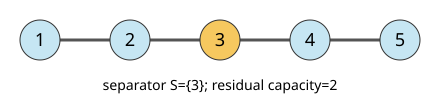

In [7]:
# A fixed SVG has no layout randomness, external fonts, or plotting dependency.
svg = let
    image = """<svg xmlns="http://www.w3.org/2000/svg" width="440" height="100" viewBox="0 0 440 100" role="img" aria-label="Path 1-2-3-4-5 with separator vertex 3">
<path d="M40 40H400" fill="none" stroke="#555" stroke-width="3"/>
"""
    for (i,cx) in enumerate((40,130,220,310,400))
        fill = i == 3 ? "#f6c85f" : "#c6e6f3"
        image *= """<circle cx="$cx" cy="40" r="20" fill="$fill" stroke="#333"/><text x="$cx" y="46" text-anchor="middle" font-family="sans-serif" font-size="18">$i</text>"""
    end
    image * """<text x="220" y="90" text-anchor="middle" font-family="sans-serif" font-size="14">separator S={3}; residual capacity=2</text></svg>"""
end
struct TutorialSVG
    content::String
end
Base.show(io::IO, ::MIME"image/svg+xml", figure::TutorialSVG) = print(io, figure.content)
Base.show(io::IO, ::MIME"text/plain", ::TutorialSVG) = print(io, "Path 1–2–[3]–4–5; separator S={3}")
display(TutorialSVG(svg));

For a fixed value $s=x_3$, the same objective becomes

$$E_B(x\mid s)=3+s+\underbrace{x_1+(1-2s)x_2-2x_1x_2}_{\{1,2\}}
+\underbrace{(1-2s)x_4+x_5-2x_4x_5}_{\{4,5\}}.$$

The boundary interactions change the linear coefficients; an induced subgraph alone would omit them. Enumerating **both** values of $s$, solving each residual component exactly, assembling each complete branch, and comparing the original energies covers every original assignment. A branch that initially looks worse must still complete. Here the branch minima are 3 for $s=0$ and 0 for $s=1$.

Graph discovery supplies a plan, not an optimality certificate. Interrupted enumeration, exhausted budgets, incomplete reconstruction, or missing child certificates prevent a package global certificate.

In [8]:
energy_b(x) = 3 + sum(x) - 2*sum(x[i]*x[i+1] for i in 1:4)
model_b = qubo_model(ones(5), [(i,i+1,-2) for i in 1:4]; offset=3)
states_b = binary_states(5)
oracle_b = minimum(energy_b(x) for x in states_b)
@assert oracle_b == 0
@assert all(original_energy(model_b,x) == energy_b(x) for x in states_b)
branch_minima = [minimum(energy_b(x) for x in states_b if x[3] == s) for s in 0:1]
@assert branch_minima == [3,0]
separator_b = audited(tiny_solve(model_b; strategy=:separator, capacity=2, separator=[3]), energy_b)
plan_b = separator_b.data["separator"]
@assert plan_b["indices"] == [3]
@assert plan_b["residual_components"] == [[1,2],[4,5]]
@assert plan_b["required_branches"] == plan_b["completed_branches"] == 2
@assert plan_b["certified_branches"] == 0 && !plan_b["proof_complete"]
@assert separator_b.energy == oracle_b && separator_b.bits == ones(Int,5)
println((; assignment=separator_b.bits, original_energy=energy_b(separator_b.bits),
          branch_minima, completed_branches=plan_b["completed_branches"],
          certified_branches=plan_b["certified_branches"], status=separator_b.status))

(assignment = [1, 1, 1, 1, 1], original_energy = 0, branch_minima = [3, 0], completed_branches = 2, certified_branches = 0, status = MathOptInterface.LOCALLY_SOLVED)


In [9]:
# Inspect compact public diagnostics, omitting transient timing fields.
for call in separator_b.data["calls"]
    println((; branch=call["branch"], selected=call["selected_indices"],
        original_to_reduced=sort!(collect(call["original_to_reduced"])),
        boundary=sort!(collect(call["boundary_fixed_variables"])),
        child_status=call["public_status"]))
end
articulation_b = audited(tiny_solve(model_b; strategy=:separator, capacity=2, separator=:articulation), energy_b)
@assert articulation_b.data["separator"]["indices"] == [3]
@assert articulation_b.data["separator"]["discovery"]["complete"]
@assert !articulation_b.data["separator"]["proof_complete"]
@assert articulation_b.energy == oracle_b
println("Automatic articulation selection chooses the same S={3}; discovery completed, package proof did not.")

(branch = 1, selected = [1, 2], original_to_reduced = 

[1 => 1, 2 => 2], boundary = [3 => 0], child_status = "LOCALLY_SOLVED")
(branch = 1, selected = [4, 5], original_to_reduced = [4 => 1, 5 => 2], boundary = [3 => 0], child_status = "LOCALLY_SOLVED")
(branch = 2, selected = [1, 2], original_to_reduced = [1 => 1, 2 => 2], boundary = [3 => 1], child_status = "LOCALLY_SOLVED")
(branch = 2, selected = [4, 5], original_to_reduced = [4 => 1, 5 => 2], boundary = [3 => 1], child_status = "LOCALLY_SOLVED")


Automatic articulation selection chooses the same S={3}; discovery completed, package proof did not.


## The limit of conditioned sweeps

Now couple every pair of six bits:

$$E_C(x)=\sum_i x_i-2\sum_{i<j}x_ix_j=2k-k^2,\qquad k=\sum_i x_i.$$

From the default all-zero incumbent, setting one bit gives energy 1 and setting two gives 0. With capacity two, no neighborhood offers **strict** improvement; equal-energy candidates keep the incumbent. Yet three simultaneous ones give −3 and all six give the global minimum −24.

This is a limitation of the existing conditioned-sweep method, not a conditioning error. Each neighborhood solves exactly with the other bits fixed at the current boundary. Even visiting every pair cannot escape this state under strict acceptance. Complete index coverage and more identical stagnant sweeps do not cover the global assignment space.

In [10]:
energy_c(x) = sum(x) - 2*sum(x[i]*x[j] for i in 1:5 for j in i+1:6)
model_c = qubo_model(ones(6), [(i,j,-2) for i in 1:5 for j in i+1:6])
states_c = binary_states(6)
oracle_c = minimum(energy_c(x) for x in states_c)
@assert oracle_c == -24
@assert all(original_energy(model_c,x) == energy_c(x) == 2*sum(x)-sum(x)^2 for x in states_c)
# Exhaustively check the stronger claim: every move of at most two bits is non-improving.
@assert minimum(energy_c(x) for x in states_c if sum(x) <= 2) == 0
sweeps_c = audited(tiny_solve(model_c; strategy=:components_then_sweeps, capacity=2), energy_c)
@assert sweeps_c.bits == zeros(Int,6) && sweeps_c.energy == 0 > oracle_c
@assert all(diff(sweeps_c.data["incumbent_energy_trace"]) .<= 0)
@assert !sweeps_c.data["separable_proof"]
println((; assignment=sweeps_c.bits, observed=sweeps_c.energy, oracle=oracle_c,
          incumbent_trace=sweeps_c.data["incumbent_energy_trace"],
          completed_sweeps=sweeps_c.data["completed_sweeps"], status=sweeps_c.status))

(assignment = [0, 0, 0, 0, 0, 0], observed = 0.0, oracle = -24, incumbent_trace = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], completed_sweeps = 1, status = MathOptInterface.LOCALLY_SOLVED)


## A constrained JuMP / ToQUBO model

Select exactly one of two choices:

$$\max\;f(a,b)=5+3a+2b,\qquad a+b=1,\qquad a,b\in\{0,1\}.$$

The independently known source optimum is 8 at $(1,0)$. For this equality and native binary variables, ToQUBO needs no slack or encoding bits. Its target maximizes

$$Q_\lambda(a,b)=5+3a+2b-\lambda(a+b-1)^2.$$

With $\lambda=0.1$, the **global QUBO** optimum is 9.9 at $(1,1)$: source objective 10, but infeasible. With $\lambda=10$, the global QUBO optimum decodes to the feasible source optimum 8. A negative penalty hint is required for this maximization model.

We use the public compiler-only optimizer, inspect the target size **before** exhaustive work, copy that target to decomposition, then decode the full returned bit dictionary through `ToQUBO.project_original_state`. This makes the compile/solve/decode boundary visible without an automatic penalty-refinement loop. It does not attach a result to the compiler-only JuMP model, so the source values and feasibility below are explicitly computed from the decoded assignment.

In [11]:
function constrained_example(penalty)
    compiler = ToQUBO.Optimizer()
    model = JuMP.Model(() -> compiler)
    @variable(model, x[1:2], Bin)
    @objective(model, Max, 5 + 3*x[1] + 2*x[2])
    constraint = @constraint(model, x[1] + x[2] == 1)
    set_attribute(constraint, ToQUBO.Attributes.ConstraintEncodingPenaltyHint(), -penalty)
    set_attribute(model, ToQUBO.Attributes.MaxPenaltyUpdates(), 0)
    optimize!(model) # compilation only: no child solver is installed
    target = MOI.get(compiler, ToQUBO.Attributes.TargetModel())
    target_variables = MOI.get(target, MOI.ListOfVariableIndices())
    states = binary_states(length(target_variables)) # guard before any enumeration/dispatch
    @assert length(target_variables) == 2
    @assert isempty(ToQUBO.auxiliary_variables(compiler))
    @assert MOI.get(compiler, ToQUBO.Attributes.AppliedPenalty(), index(constraint)) == -penalty
    decoded(bits) = ToQUBO.project_original_state(compiler, Dict(zip(target_variables,bits)))
    scalar(bits) = begin
        source_values = decoded(bits)
        u,v = source_values[index(x[1])], source_values[index(x[2])]
        5 + 3*u + 2*v - penalty*(u+v-1)^2
    end
    @assert all(original_energy(target,bits) ≈ scalar(bits) for bits in states)
    # Conditioning on the first target bit leaves one capacity-fitting residual bit.
    result = audited(tiny_solve(target; strategy=:separator, capacity=1, separator=[1]), scalar)
    projected = decoded(result.bits)
    a,b = projected[index(x[1])], projected[index(x[2])]
    residual = a + b - 1
    source_objective = 5 + 3*a + 2*b
    source_feasible = a in (0,1) && b in (0,1) && residual == 0
    source_oracle = maximum(5+3*u+2*v for (u,v) in binary_states(2) if u+v == 1)
    compiled_oracle = maximum(scalar(bits) for bits in states)
    @assert result.energy ≈ compiled_oracle
    @assert result.data["separator"]["completed_branches"] == 2
    @assert !result.data["separator"]["proof_complete"]
    return (; result, decoded=[a,b], source_objective, source_feasible, residual,
              source_oracle, compiled_oracle, compiled_dimension=length(target_variables))
end
weak_d = constrained_example(0.1)
strong_d = constrained_example(10.0)
@assert !weak_d.source_feasible && weak_d.source_objective == 10 && weak_d.result.energy ≈ 9.9
@assert strong_d.decoded == [1,0]
@assert strong_d.source_feasible && strong_d.source_objective == strong_d.source_oracle == 8
for (name,example) in (("weak",weak_d),("sufficient",strong_d))
    println((; penalty=name, bits=example.result.bits, decoded=example.decoded,
        compiled_energy=example.result.energy, source_objective=example.source_objective,
        source_residual=example.residual, source_feasible=example.source_feasible,
        source_oracle=example.source_oracle, status=example.result.status))
end

(penalty = "weak", bits = [1, 1], decoded = [1.0, 1.0], compiled_energy = 9.9, source_objective = 10.0, source_residual = 1.0, source_feasible = false, source_oracle = 8, status = MathOptInterface.LOCALLY_SOLVED)
(penalty = "sufficient", bits = [1, 0], decoded = [1.0, 0.0], compiled_energy = 8.0, source_objective = 8.0, source_residual = 0.0, source_feasible = true, source_oracle = 8, status = MathOptInterface.LOCALLY_SOLVED)


### When source optimality transfers

For this two-choice example, feasible states have source values 7 and 8; infeasible states have penalized values `5−λ` and `10−λ`. Thus **λ > 2** makes every compiled maximizer source feasible, and the zero penalty on feasible states preserves their objective ordering. At λ = 2 an infeasible state ties the source optimum, so an arbitrary returned optimum need not be feasible.

In general the transfer needs a valid encoding that represents the source decisions, sufficient penalties that exclude infeasible global optima, correct decoding, and an exact completed solve of the compiled problem. Slack and quadratization bits can enlarge the target. Always check the compiled dimension, original bounds/integrality/constraints, and original objective. This fixture supplies exhaustive external evidence; it does not turn a missing public child certificate into a package certificate.

## Compare observations, proof, and work

The oracle column is the original logical QUBO optimum for that row, including its constant. The two source rows compare **compiled** energy with the compiled oracle; source feasibility and the feasible source optimum 8 are separate above. Direct solving has one solver call; composite rows count child calls and parent candidate evaluations. Search assignments are `Σ 2^(child dimension)` for the complete exhaustive child calls, not a claim that one returned row or a smaller child means equal computational cost.

In [12]:
comparison_rows = [
    ("A / direct", direct_a, oracle_a),
    ("A / components", components_a, oracle_a),
    ("B / separator", separator_b, oracle_b),
    ("B / articulation", articulation_b, oracle_b),
    ("C / sweeps", sweeps_c, oracle_c),
    ("D / weak penalty", weak_d.result, weak_d.compiled_oracle),
    ("D / sufficient penalty", strong_d.result, strong_d.compiled_oracle),
]
table = "| Method | Observed energy | Oracle optimum | Public status | Package global proof | Capacity | Calls | Child assignments | Parent evaluations | Sweeps | Branches |\n"
table *= "| --- | ---: | ---: | --- | --- | ---: | ---: | ---: | ---: | ---: | --- |\n"
for (name,result,oracle) in comparison_rows
    data = result.data
    calls = data === nothing ? 1 : data["completed_calls"]
    assignments = data === nothing ? 1 << length(result.bits) :
        sum(1 << length(call["selected_indices"]) for call in data["calls"])
    evaluations = data === nothing ? "—" : string(data["candidate_evaluations"])
    sweeps = data === nothing ? 0 : data["completed_sweeps"]
    plan = data === nothing ? nothing : data["separator"]
    branches = plan === nothing ? "—" : "$(plan["completed_branches"])/$(plan["required_branches"])"
    proof = data === nothing ? false : plan === nothing ? data["separable_proof"] : plan["proof_complete"]
    @assert !proof
    table *= "| $name | $(result.energy) | $oracle | $(result.status) | $proof | $(result.capacity) | $calls | $assignments | $evaluations | $sweeps | $branches |\n"
end
struct TutorialTable
    content::String
end
Base.show(io::IO, ::MIME"text/markdown", result::TutorialTable) = print(io, result.content)
Base.show(io::IO, ::MIME"text/plain", result::TutorialTable) = print(io, result.content)
display(TutorialTable(table));

| Method | Observed energy | Oracle optimum | Public status | Package global proof | Capacity | Calls | Child assignments | Parent evaluations | Sweeps | Branches |
| --- | ---: | ---: | --- | --- | ---: | ---: | ---: | ---: | ---: | --- |
| A / direct | 0.0 | 0 | LOCALLY_SOLVED | false | 4 | 1 | 16 | — | 0 | — |
| A / components | 0.0 | 0 | LOCALLY_SOLVED | false | 2 | 2 | 8 | 9 | 0 | — |
| B / separator | 0.0 | 0 | LOCALLY_SOLVED | false | 2 | 4 | 16 | 21 | 0 | 2/2 |
| B / articulation | 0.0 | 0 | LOCALLY_SOLVED | false | 2 | 4 | 16 | 21 | 0 | 2/2 |
| C / sweeps | 0.0 | -24 | LOCALLY_SOLVED | false | 2 | 6 | 24 | 25 | 1 | — |
| D / weak penalty | 9.9 | 9.9 | LOCALLY_SOLVED | false | 1 | 2 | 4 | 9 | 0 | 2/2 |
| D / sufficient penalty | 8.0 | 8.0 | LOCALLY_SOLVED | false | 1 | 2 | 4 | 9 | 0 | 2/2 |


## Exercises

Use the hidden solutions to check your reasoning. Each exercise stays within the tiny-instance work bounds.

In [13]:
# EXERCISE 1: Change A's constant from 5 to 12. Predict the new optimum
# and whether the optimal assignment or component topology changes.
nothing

In [14]:
# SOLUTION (hidden in workshop version):
shifted = qubo_model([-3,2,-1,-2], [(1,2,4),(3,4,2)]; offset=12)
shifted_result = tiny_solve(shifted; capacity=2)
@assert shifted_result.bits == components_a.bits
@assert shifted_result.energy == minimum(energy_a(x)+7 for x in binary_states(4)) == 7
println("The optimum increases by 7; the assignment and components are unchanged.")

The optimum increases by 7; the assignment and components are unchanged.


In [15]:
# EXERCISE 2: Allow only one child call on B. Does finding a valid full
# incumbent complete both separator branches? Inspect status and progress.
nothing

In [16]:
# SOLUTION (hidden in workshop version):
limited_b = tiny_solve(model_b; strategy=:separator, capacity=2, separator=[3], child_calls=1)
@assert limited_b.status == MOI.ITERATION_LIMIT
@assert limited_b.energy == energy_b(limited_b.bits)
@assert limited_b.data["separator"]["completed_branches"] < 2
@assert !limited_b.data["separator"]["proof_complete"]
println((; status=limited_b.status, valid_incumbent=limited_b.bits,
    completed_branches=limited_b.data["separator"]["completed_branches"],
    required_branches=limited_b.data["separator"]["required_branches"]))

(status = MathOptInterface.ITERATION_LIMIT, valid_incumbent = [0, 0, 0, 0, 0], completed_branches = 0, required_branches = 2)


In [17]:
# EXERCISE 3: At penalty λ=2 in D, list every compiled maximizer and
# check whether each is source feasible. Explain why a tie matters.
nothing

In [18]:
# SOLUTION (hidden in workshop version):
threshold_states = binary_states(2)
threshold_energy(x) = 5 + 3*x[1] + 2*x[2] - 2*(sum(x)-1)^2
threshold_optimum = maximum(threshold_energy(x) for x in threshold_states)
threshold_maximizers = filter(x -> threshold_energy(x) == threshold_optimum, threshold_states)
@assert Set(Tuple.(threshold_maximizers)) == Set(((1,0),(1,1)))
@assert any(sum(x) != 1 for x in threshold_maximizers)
println((; compiled_optimum=threshold_optimum, maximizers=threshold_maximizers,
    feasible=[sum(x)==1 for x in threshold_maximizers]))

(compiled_optimum = 8, maximizers = [[1, 0], [1, 1]], feasible = Bool[1, 0])


## Summary

Correct conditioning preserves boundary terms and offsets; complete reconstruction must be checked against the original objective. Independent components compose, and complete separator enumeration covers the original search space when every required residual is solved exactly. Coupled sweeps have a restricted search space and can stagnate above the global optimum even with globally solved neighborhoods.

The method's conditional guarantee, the public certificate for one invocation, and independent optimum agreement are separate claims. ExactSampler's completed enumeration is global; its public `LOCALLY_SOLVED` status remains conservative. Decomposition does not promote it. The constrained example additionally needs sufficient penalties and correct decoding: a globally optimal compiled sample can be source infeasible.

## Optional integrations and evidence

The [QUBO ecosystem design](https://github.com/JuliaQUBO/QUBO.jl/blob/c0f39896da730a40d1b90321e663e15b13215825/docs/src/design.md) describes the entrypoint/compiler/driver/tooling boundaries. This standalone development pin demonstrates the working local milestone; it is not evidence of registry or stable-release adoption.

[QUBOBenchmarks PR #31](https://github.com/JuliaQUBO/QUBOBenchmarks.jl/pull/31) records a bounded exact-route campaign: direct solving was faster on its tiny paired controls, while decomposition covered parents larger than the permitted child capacity. Its negative-monomial fixtures and benchmark-only certificate adapter limit generalization. [QUBODecomposition PR #25](https://github.com/JuliaQUBO/QUBODecomposition.jl/pull/25) compares all-row versus compact certified results on two fixtures after the same full search. It reduces parent row processing, but five timing pairs and a retained GC outlier do not establish a general speedup or native best-only search. We link that evidence without rerunning a performance campaign or copying its adapters.

Optional [QSplit artifact exchange](https://github.com/JuliaQUBO/QUBOBenchmarks.jl/issues/28), [CWL/StreamFlow execution](https://github.com/JuliaQUBO/QUBOBenchmarks.jl/issues/26), and [heterogeneous routing and later methods](https://github.com/JuliaQUBO/QUBO.jl/issues/75) remain with their owning trackers. They require separate APIs/evidence and are outside this lesson's execution path. [Certified preprocessing](https://github.com/JuliaQUBO/QUBODecomposition.jl/issues/16) and [voting/repair](https://github.com/JuliaQUBO/QUBODecomposition.jl/issues/15) are separate package work.

## References

- QUBODecomposition source at `3a9e78de5022a62b41fabdc9995e81c8e5cbb785`: [guarantees](https://github.com/JuliaQUBO/QUBODecomposition.jl/blob/3a9e78de5022a62b41fabdc9995e81c8e5cbb785/docs/src/guarantees.md), [statuses](https://github.com/JuliaQUBO/QUBODecomposition.jl/blob/3a9e78de5022a62b41fabdc9995e81c8e5cbb785/docs/src/results.md), [strategies](https://github.com/JuliaQUBO/QUBODecomposition.jl/blob/3a9e78de5022a62b41fabdc9995e81c8e5cbb785/docs/src/strategies.md), [budgets](https://github.com/JuliaQUBO/QUBODecomposition.jl/blob/3a9e78de5022a62b41fabdc9995e81c8e5cbb785/docs/src/budgets.md), and [ToQUBO examples](https://github.com/JuliaQUBO/QUBODecomposition.jl/blob/3a9e78de5022a62b41fabdc9995e81c8e5cbb785/examples/toqubo/README.md).
- QSplit at `4da64b072e702953038addd51cdf54f97f0f9516`: [interaction neighborhoods](https://github.com/alpha-unito/QSplit/blob/4da64b072e702953038addd51cdf54f97f0f9516/qsplit/splitting/split_k_interactions.py) select induced submodels; [conditional conflict repair](https://github.com/alpha-unito/QSplit/blob/4da64b072e702953038addd51cdf54f97f0f9516/qsplit/conflict_resolution/local_search.py) folds fixed-variable interactions into local linear terms. These are explanatory references, not identical outer algorithms.
- D-Wave Hybrid [EnergyImpactDecomposer](https://github.com/dwavesystems/dwave-hybrid/blob/ec17a700b0250123da9909ec82db4ecb2516993d/hybrid/decomposers.py) provides neighborhood-selection context; [QUBOTools fixing/lifting](https://github.com/JuliaQUBO/QUBOTools.jl/blob/edb0fe43020abd009d795361a64dd87f73f8250d/src/library/form/form.jl) supplies the public conditioning primitives used by QUBODecomposition.
- ToQUBO [source-feasibility and refinement](https://github.com/JuliaQUBO/ToQUBO.jl/blob/481ff101d60372124a42c49ff1f2692664b699c7/docs/src/manual/5-refinement.md) explains penalty updates; this notebook fixes each penalty and performs no automatic refinement.

## Acknowledgments

Maintained by JuliaQUBO with SECQUOIA and PSR Energy. The fixtures, scalar audits, SVG, prose, and exercises here are original teaching material. Package examples and the pinned QSplit/D-Wave references informed the explanation; no QSplit or D-Wave source implementation is copied into these cells.

<div align="center">
<a href="#top-jl-12-decomposition">🔝 Go back to the top 🔝</a>
</div>